**Milestone 3 Ruggiero DSC 640**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("nationaldatabaseofchildcareprices.xlsx")
df.head()

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.42,4.41,6.32,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.93,5.72,6.11,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.0,1.0
2,Alabama,AL,Autauga County,1001,2010,6.21,5.57,6.78,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.0,1.0
3,Alabama,AL,Autauga County,1001,2011,7.55,8.13,7.03,6.2,6.3,...,95.28,3.0,94.25,1.0,111.2,1.0,111.2,3.0,110.0,1.0
4,Alabama,AL,Autauga County,1001,2012,8.60,8.88,8.29,6.7,6.4,...,99.22,3.0,98.53,1.0,115.8,1.0,115.8,3.0,115.0,1.0


In [8]:
list(df.columns)

['State_Name',
 'State_Abbreviation',
 'County_Name',
 'County_FIPS_Code',
 'StudyYear',
 'UNR_16',
 'FUNR_16',
 'MUNR_16',
 'UNR_20to64',
 'FUNR_20to64',
 'MUNR_20to64',
 'FLFPR_20to64',
 'FLFPR_20to64_Under6',
 'FLFPR_20to64_6to17',
 'FLFPR_20to64_Under6_6to17',
 'MLFPR_20to64',
 'PR_F',
 'PR_P',
 'MHI',
 'ME',
 'FME',
 'MME',
 'MHI_2018',
 'ME_2018',
 'FME_2018',
 'MME_2018',
 'TotalPop',
 'OneRace',
 'OneRace_W',
 'OneRace_B',
 'OneRace_I',
 'OneRace_A',
 'OneRace_H',
 'OneRace_Other',
 'TwoRaces',
 'Hispanic',
 'Households',
 'H_Under6_BothWork',
 'H_Under6_FWork',
 'H_Under6_MWork',
 'H_Under6_SingleM',
 'H_6to17_BothWork',
 'H_6to17_Fwork',
 'H_6to17_Mwork',
 'H_6to17_SingleM',
 'EMP_M',
 'MEMP_M',
 'FEMP_M',
 'EMP_Service',
 'MEMP_Service',
 'FEMP_Service',
 'EMP_Sales',
 'MEMP_Sales',
 'FEMP_Sales',
 'EMP_N',
 'MEMP_N',
 'FEMP_N',
 'EMP_P',
 'MEMP_P',
 'FEMP_P',
 'iUNR_16',
 'iFUNR_16',
 'iMUNR_16',
 'iUNR_20to64',
 'iFUNR_20to64',
 'iMUNR_20to64',
 'iFLFPR_20to64',
 'iFLFPR_2

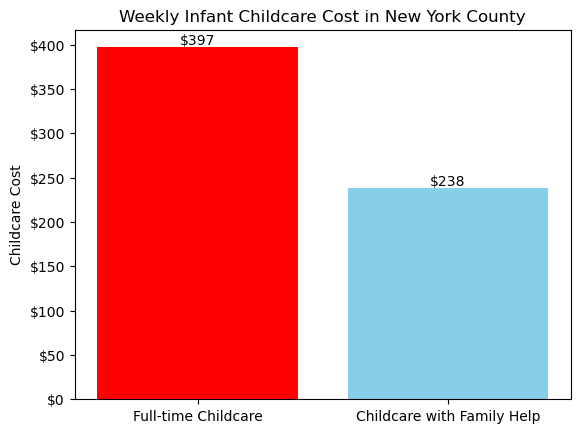

In [34]:
#***************************************************
#Visualization for the handout

ny_2018 = df[(df["County_Name"] == "New York County") & (df["StudyYear"] == 2018)].iloc[0]

weekly_cost = float(str(ny_2018["MCInfant"]).replace("$", "").strip())

#calculate weekly cost with family help
weekly_with_help = weekly_cost * (3/5)

labels = ["Full-time Childcare", "Childcare with Family Help"]
values = [weekly_cost, weekly_with_help]

from matplotlib.ticker import StrMethodFormatter

#add both costs to bar chart
plt.figure()
plt.bar(labels, values, color=["Red", "skyblue"]) 
plt.ylabel("Childcare Cost")
#add dollar signs to the y axis numbers
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Weekly Infant Childcare Cost in New York County")

plt.text(0, values[0], f"${values[0]:,.0f}", ha="center", va="bottom")
plt.text(1, values[1], f"${values[1]:,.0f}", ha="center", va="bottom")
plt.savefig("ny_infant_cost.png", dpi=300, bbox_inches='tight')

plt.show()



In [44]:
#**************************************************************
#calculating the cost saved for college based on 2018 costs and NY County

#get weekly costs for each age group
weekly_costs = {
    "infant": float(str(ny_2018["MCInfant"]).replace("$", "").strip()),
    "toddler": float(str(ny_2018["MCToddler"]).replace("$", "").strip()),
    "preschool": float(str(ny_2018["MCPreschool"]).replace("$", "").strip()),
    "preschool_to_sa": float(str(ny_2018["MC54toSA"]).replace("$", "").strip()),
    "school_age": float(str(ny_2018["MCSA"]).replace("$", "").strip())
}

#calculate how many weeks/years there are for each age level
weeks_per_year = 52
#multiply the number of years by the number of weeks in a year (52)
age_in_weeks = {
    #0-23 months
    "infant": 2*weeks_per_year,
    #24-35 months
    "toddler": 1*weeks_per_year,
    #36 months to 54 months
    "preschool": 1.5*weeks_per_year,
    #54 months to 60 months
    "preschool_to_sa": 0.5*weeks_per_year,
    #assume childcare until 10 years old
    "school_age": 5*weeks_per_year
}

#total cost for childcare up to 10 years old
total_cost = sum(weekly_costs[age] * age_in_weeks[age] for age in weekly_costs)
print(total_cost)


146725.28


In [50]:
#comparison total cost if 2 days a week a family member helps watch the child
total_cost_with_help = sum(weekly_costs[age] * age_in_weeks[age] * (3/5) for age in weekly_costs)
print(total_cost_with_help)

88035.16799999999


In [58]:
#***************************************
#For the video: create a pie chart that shows avg US rent vs childcare cost vs median household income for NY
ny_2018 = df[(df["County_Name"] == "New York County") & (df["StudyYear"] == 2018)]

#get MHI value (median household income)
mhi_value = ny_2018["MHI"].values[0]

print(mhi_value)

82459.0


Monthly income:  6871.583333333333
Monthly childcare cost:  1720.3333333333333
Other values:  951.25


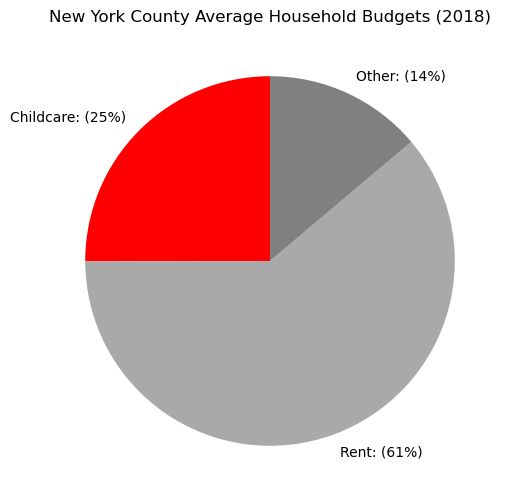

In [112]:
#create the pie chart 
#number found previously for weekly childcare cost full time (infant)
weekly_childcare = 397
#looked up the monthly avg rent for new york county
rent = 4200

monthly_income = mhi_value / 12
print("Monthly income: ", monthly_income)

monthly_childcare = weekly_childcare * (52/12)
print("Monthly childcare cost: ", monthly_childcare)

other = monthly_income - (monthly_childcare + rent)
print("Other values: ", other)

labels = [
    f"Childcare: ({monthly_childcare/monthly_income*100:.0f}%)", 
    f"Rent: ({rent/monthly_income*100:.0f}%)", 
    f"Other: ({other/monthly_income*100:.0f}%)"
]

sizes = [monthly_childcare, rent, other]
colors = ["red", "darkgray", "gray"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, startangle=90)
plt.title("New York County Average Household Budgets (2018)")
plt.savefig("budgets_full.png", dpi=300, bbox_inches='tight')
plt.show()

Monthly income:  6871.583333333333
Monthly childcare cost:  1032.1999999999998
Other values:  1639.3833333333332


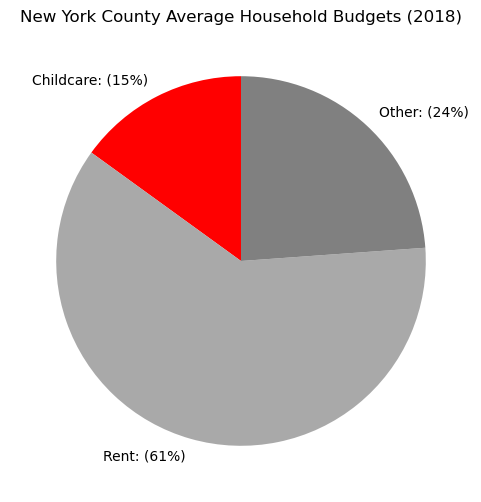

In [114]:
#create the pie chart 
#number found previously for weekly childcare cost full time (infant)
weekly_childcare = 397
#looked up the monthly avg rent for new york county
rent = 4200

monthly_income = mhi_value / 12
print("Monthly income: ", monthly_income)

#calculate new monthly childcare with only 3/5 days instead of all 5
monthly_childcare = weekly_childcare * (52/12) * (3/5)
print("Monthly childcare cost: ", monthly_childcare)

other = monthly_income - (monthly_childcare + rent)
print("Other values: ", other)

labels = [
    f"Childcare: ({monthly_childcare/monthly_income*100:.0f}%)", 
    f"Rent: ({rent/monthly_income*100:.0f}%)", 
    f"Other: ({other/monthly_income*100:.0f}%)"
]

sizes = [monthly_childcare, rent, other]
colors = ["red", "darkgray", "gray"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, startangle=90)
plt.title("New York County Average Household Budgets (2018)")
plt.savefig("budgets_half.png", dpi=300, bbox_inches='tight')
plt.show()